# Sliding Window, Image Pyramids & Advanced Detection Methods

## Overview
This notebook covers fundamental and advanced techniques for object detection in computer vision:
1. **Sliding Window**: A basic detection approach that scans an image with a fixed-size window
2. **Image Pyramids**: Handling objects at different scales
3. **Viola-Jones Face Detector**: A cascade-based face detection algorithm
4. **Haar Cascades**: Pre-trained classifiers for face detection
5. **HOG+SVM Pedestrian Detector**: Hand-crafted features combined with SVM for pedestrian detection

These techniques form the foundation of modern object detection (before deep learning dominated the field).

In [16]:
# Import necessary libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## Part 1: Sliding Window Technique

### What is Sliding Window?
The sliding window is one of the simplest object detection methods:
- Takes a fixed-size window of the image
- Slides it across the entire image (left-to-right, top-to-bottom)
- At each position, extracts features and checks if the window contains the target object
- Records all positive detections (with their locations and confidence scores)

### Why Sliding Window?
✓ Simple to understand and implement
✓ Can detect objects at any location
✗ Computationally expensive (checks many positions)
✗ Only works for fixed object sizes (solved by image pyramids)

### Mathematical Concept
For an image of size (H, W) and window of size (h, w) with stride s:
- Number of positions = floor((H-h)/s) × floor((W-w)/s)
- Each position requires feature extraction and classification

Generated 81 windows from 200x200 image
With window size 40x40 and stride 20


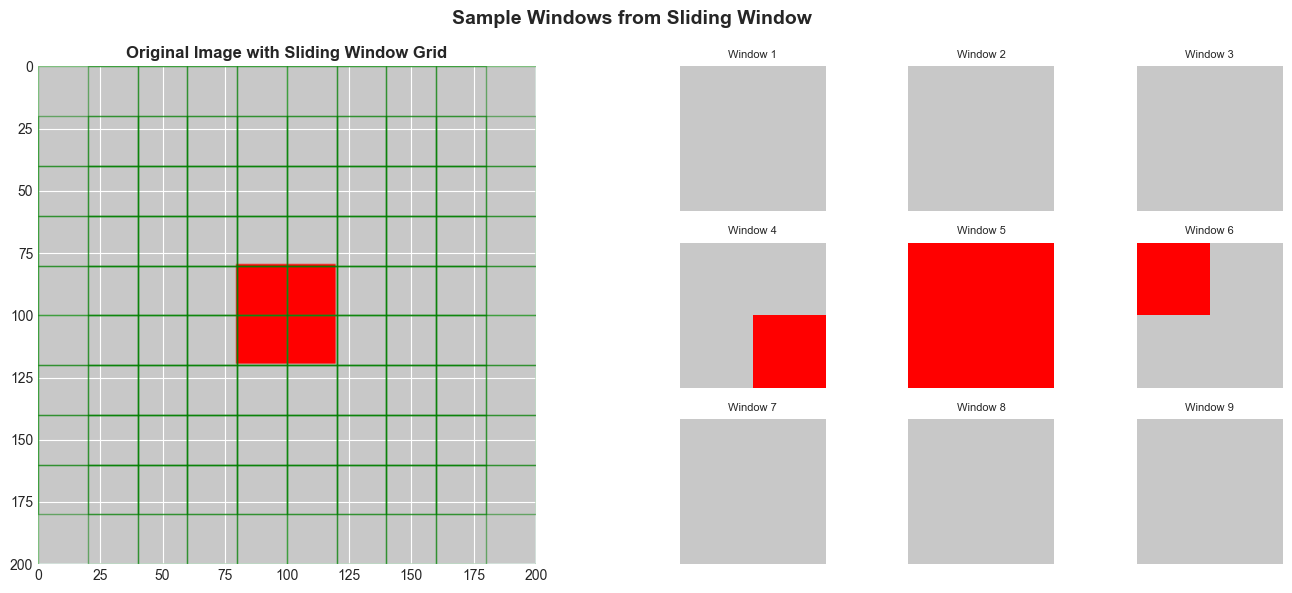

✓ Sliding window visualization complete!


In [17]:
# Sliding Window Implementation
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def sliding_window(image, window_size=(64, 64), stride=16):
    """
    Generate sliding windows over an image.

    Parameters:
    -----------
    image : ndarray
        Input image
    window_size : tuple
        (height, width) of the window
    stride : int
        Step size for sliding (pixels)

    Returns:
    --------
    windows : list of (x, y, window) tuples
    """
    windows = []

    h, w = image.shape[:2]
    win_h, win_w = window_size

    for y in range(0, h - win_h + 1, stride):
        for x in range(0, w - win_w + 1, stride):

            # Extract window
            window = image[y:y + win_h, x:x + win_w]

            windows.append((x, y, window))

    return windows


# Create a simple test image
test_image = np.ones((200, 200, 3), dtype=np.uint8) * 200

# Add a red square in the middle to simulate an object
test_image[80:120, 80:120] = [0, 0, 255]

# Generate windows
windows = sliding_window(test_image, window_size=(40, 40), stride=20)

print(f"Generated {len(windows)} windows from {test_image.shape[0]}x{test_image.shape[1]} image")
print("With window size 40x40 and stride 20")


# =========================
# Visualization
# =========================

fig = plt.figure(figsize=(14, 6))

# -----------------------------------
# LEFT: Original image with grid
# -----------------------------------
ax1 = fig.add_subplot(1, 2, 1)

ax1.imshow(cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB))
ax1.set_title(
    'Original Image with Sliding Window Grid',
    fontsize=12,
    fontweight='bold'
)

# Draw sliding window rectangles
for (x, y, _) in windows:
    rect = Rectangle(
        (x, y),
        40,
        40,
        linewidth=1,
        edgecolor='green',
        facecolor='none',
        alpha=0.5
    )
    ax1.add_patch(rect)

ax1.set_xlim(0, test_image.shape[1])
ax1.set_ylim(test_image.shape[0], 0)

# -----------------------------------
# RIGHT: Sample windows
# -----------------------------------

# Create a 3x3 grid on the right side
sample_indices = np.linspace(0, len(windows)-1, 9, dtype=int)

for i, idx in enumerate(sample_indices):

    ax = fig.add_subplot(3, 6, (i % 3) + 4 + (i // 3) * 6)

    _, _, window = windows[idx]

    ax.imshow(cv2.cvtColor(window, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Window {i+1}', fontsize=8)

    ax.axis('off')

# Main title
fig.suptitle(
    'Sample Windows from Sliding Window',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

print("✓ Sliding window visualization complete!")

## Part 2: Image Pyramid

### Why Image Pyramids?
Sliding window only works for fixed object sizes. But objects in real images appear at different scales!

**Image Pyramid Solution**:
- Create multiple versions of the image at different scales
- Run sliding window on each scale level
- Detects objects at various sizes

### Types of Image Pyramids
1. **Gaussian Pyramid**: Downsamples (reduces) image by blurring and subsampling
2. **Laplacian Pyramid**: Differences between Gaussian levels (captures edges at different scales)

### How It Works
- Level 0: Original image (scale = 1.0)
- Level 1: Half resolution (scale = 0.5)
- Level 2: Quarter resolution (scale = 0.25)
- ... and so on

**Key Insight**: A small object in the original image becomes a larger object in a downsampled version!

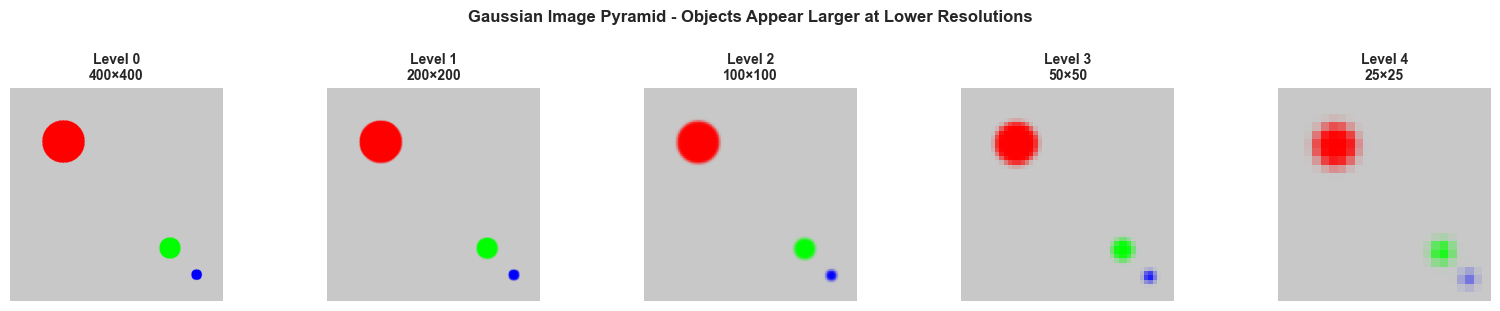

Image Pyramid Scales:
  Level 0: (400, 400, 3) (scale: 1.00)
  Level 1: (200, 200, 3) (scale: 0.50)
  Level 2: (100, 100, 3) (scale: 0.25)
  Level 3: (50, 50, 3) (scale: 0.12)
  Level 4: (25, 25, 3) (scale: 0.06)


In [18]:
# Image Pyramid Implementation
def build_gaussian_pyramid(image, levels=4):
    """
    Build a Gaussian pyramid from an image.
    
    Parameters:
    -----------
    image : ndarray
        Input image
    levels : int
        Number of pyramid levels
    
    Returns:
    --------
    pyramid : list of images
    """
    pyramid = [image]
    for i in range(1, levels):
        # Downsample by blurring and taking every 2nd pixel
        downsampled = cv2.pyrDown(image)
        image = downsampled
        pyramid.append(image)
    return pyramid

# Create a test image with objects at different scales
test_pyramid_img = np.ones((400, 400, 3), dtype=np.uint8) * 200

# Add objects of different sizes
cv2.circle(test_pyramid_img, (100, 100), 40, (0, 0, 255), -1)  # Red circle, large
cv2.circle(test_pyramid_img, (300, 300), 20, (0, 255, 0), -1)  # Green circle, medium
cv2.circle(test_pyramid_img, (350, 350), 10, (255, 0, 0), -1)  # Blue circle, small

# Build pyramid
pyramid = build_gaussian_pyramid(test_pyramid_img, levels=5)

# Visualize pyramid
fig, axes = plt.subplots(1, 5, figsize=(16, 3))

for idx, level_img in enumerate(pyramid):
    ax = axes[idx]
    ax.imshow(cv2.cvtColor(level_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'Level {idx}\n{level_img.shape[0]}×{level_img.shape[1]}', fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Gaussian Image Pyramid - Objects Appear Larger at Lower Resolutions', 
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Image Pyramid Scales:")
for i, level_img in enumerate(pyramid):
    scale = 2 ** (-i)
    print(f"  Level {i}: {level_img.shape} (scale: {scale:.2f})")

## Part 3: Viola-Jones Face Detector

### Historical Significance
Published in 2001 by Paul Viola and Michael Jones, this was a breakthrough in real-time face detection.

### Key Components

#### 1. **Haar Features**
- Simple rectangular features inspired by Haar wavelets
- Computed as the difference between sum of pixels in white and black regions
- Very fast to compute using **integral images**

#### 2. **Integral Images**
- Allows computing any rectangular region sum in O(1) time
- Formula: `I(x,y) = sum of all pixels (0,0) to (x,y)`

#### 3. **AdaBoost Classifier**
- Combines weak classifiers (each detecting specific Haar features) into a strong classifier
- Each weak classifier focuses on a specific feature combination

#### 4. **Cascade Classifier**
- Instead of checking all features: **cascade through stages**
- Each stage is more complex than the previous
- Early stages reject obvious negatives quickly
- Only hard examples progress to later stages
- **Result**: Massive speedup (98% windows rejected by stage 1!)

### Why So Fast?
- Haar features use integral images → O(1) computation
- Cascade rejects most negatives early → very few reach complex stages
- Can process video in real-time on CPUs

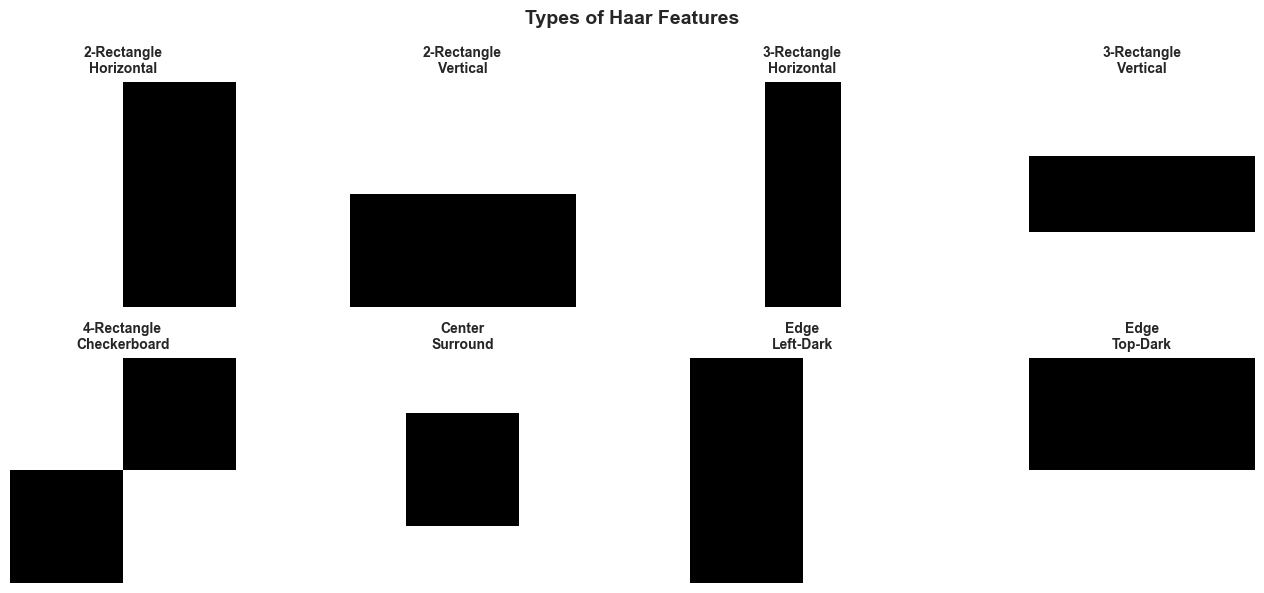

✓ These Haar features are computed on every 24×24 window
✓ Feature value = sum(white pixels) - sum(black pixels)


In [19]:
# Visualize Haar Features
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
fig.suptitle('Types of Haar Features', fontsize=14, fontweight='bold')

# Feature patterns (common in Viola-Jones)
features = []

# Feature 1: Two rectangles (horizontal)
f1 = np.zeros((24, 24), dtype=np.uint8)
f1[:, :12] = 255
f1[:, 12:] = 0
features.append(('2-Rectangle\nHorizontal', f1))

# Feature 2: Two rectangles (vertical)
f2 = np.zeros((24, 24), dtype=np.uint8)
f2[:12, :] = 255
f2[12:, :] = 0
features.append(('2-Rectangle\nVertical', f2))

# Feature 3: Three rectangles (horizontal)
f3 = np.zeros((24, 24), dtype=np.uint8)
f3[:, :8] = 255
f3[:, 8:16] = 0
f3[:, 16:] = 255
features.append(('3-Rectangle\nHorizontal', f3))

# Feature 4: Three rectangles (vertical)
f4 = np.zeros((24, 24), dtype=np.uint8)
f4[:8, :] = 255
f4[8:16, :] = 0
f4[16:, :] = 255
features.append(('3-Rectangle\nVertical', f4))

# Feature 5: Four rectangles (checkerboard)
f5 = np.zeros((24, 24), dtype=np.uint8)
f5[:12, :12] = 255
f5[:12, 12:] = 0
f5[12:, :12] = 0
f5[12:, 12:] = 255
features.append(('4-Rectangle\nCheckerboard', f5))

# Feature 6: Center surround
f6 = np.zeros((24, 24), dtype=np.uint8)
f6[:, :] = 255
f6[6:18, 6:18] = 0
features.append(('Center\nSurround', f6))

# Feature 7: Edge (left-dark)
f7 = np.zeros((24, 24), dtype=np.uint8)
f7[:, :] = 0
f7[:, 12:] = 255
features.append(('Edge\nLeft-Dark', f7))

# Feature 8: Edge (top-dark)
f8 = np.zeros((24, 24), dtype=np.uint8)
f8[:, :] = 0
f8[12:, :] = 255
features.append(('Edge\nTop-Dark', f8))

for idx, (ax, (name, feature)) in enumerate(zip(axes.flat, features)):
    ax.imshow(feature, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ These Haar features are computed on every 24×24 window")
print("✓ Feature value = sum(white pixels) - sum(black pixels)")

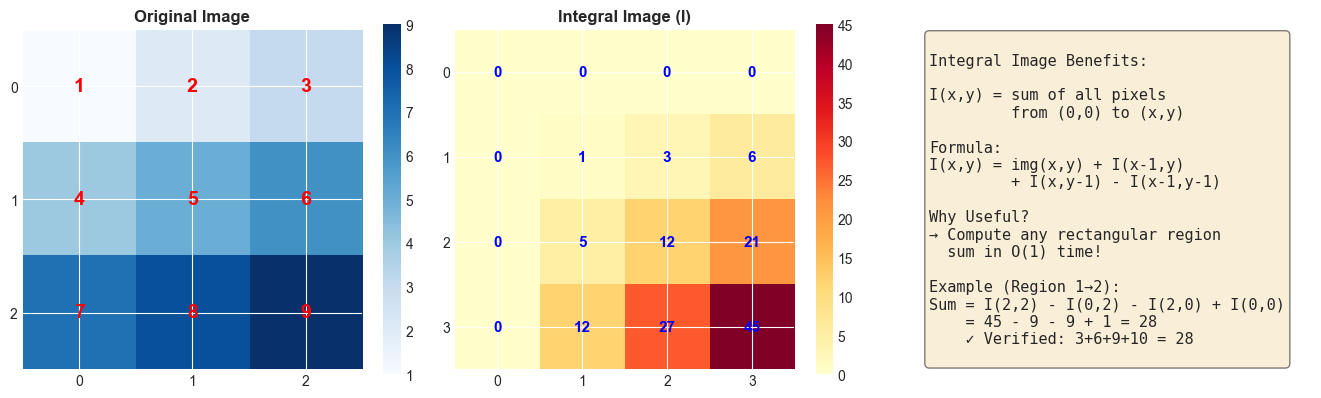

✓ Integral Image computed successfully!
Original image shape: (3, 3)
Integral image shape: (4, 4)


In [20]:
# Integral Image Visualization
def compute_integral_image(image):
    """
    Compute the integral image.
    I(x,y) = sum of all pixels from (0,0) to (x,y)
    """
    integral = cv2.integral(image)
    return integral

# Create a simple test image
simple_img = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
], dtype=np.float32)

# Compute integral image
integral = compute_integral_image(simple_img)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Original image
ax = axes[0]
im = ax.imshow(simple_img, cmap='Blues')
ax.set_title('Original Image', fontsize=12, fontweight='bold')
for i in range(simple_img.shape[0]):
    for j in range(simple_img.shape[1]):
        ax.text(j, i, str(int(simple_img[i, j])), ha='center', va='center', 
                color='red', fontweight='bold', fontsize=14)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
plt.colorbar(im, ax=ax)

# Integral image
ax = axes[1]
im = ax.imshow(integral, cmap='YlOrRd')
ax.set_title('Integral Image (I)', fontsize=12, fontweight='bold')
ax.set_xticks(range(4))
ax.set_yticks(range(4))
for i in range(integral.shape[0]):
    for j in range(integral.shape[1]):
        ax.text(j, i, str(int(integral[i, j])), ha='center', va='center', 
                color='blue', fontweight='bold', fontsize=11)
plt.colorbar(im, ax=ax)

# Explanation
ax = axes[2]
ax.axis('off')
explanation = """
Integral Image Benefits:

I(x,y) = sum of all pixels 
         from (0,0) to (x,y)

Formula:
I(x,y) = img(x,y) + I(x-1,y) 
         + I(x,y-1) - I(x-1,y-1)

Why Useful?
→ Compute any rectangular region 
  sum in O(1) time!

Example (Region 1→2):
Sum = I(2,2) - I(0,2) - I(2,0) + I(0,0)
    = 45 - 9 - 9 + 1 = 28
    ✓ Verified: 3+6+9+10 = 28
"""
ax.text(0.1, 0.5, explanation, fontsize=11, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("✓ Integral Image computed successfully!")
print(f"Original image shape: {simple_img.shape}")
print(f"Integral image shape: {integral.shape}")

## Part 4: Haar Cascade Face Detection in OpenCV

### Overview
OpenCV provides pre-trained Haar cascade classifiers for face detection. These are the practical implementation of Viola-Jones algorithm.

### How to Use
1. Load a pre-trained cascade classifier XML file
2. Use `detectMultiScale()` to detect objects in an image
3. Adjust parameters for sensitivity/specificity trade-off

### Key Parameters
- **scaleFactor**: How much image size is reduced at each scale (1.1 = 10% reduction) → Lower = more thorough but slower
- **minNeighbors**: How many neighbors each candidate should have → Higher = fewer false positives but may miss objects
- **minSize/maxSize**: Minimum/maximum object size to detect
- **flags**: Cascade usage mode

✓ Haar Cascades loaded successfully!
Face cascade loaded: True

✓ Detected 0 faces


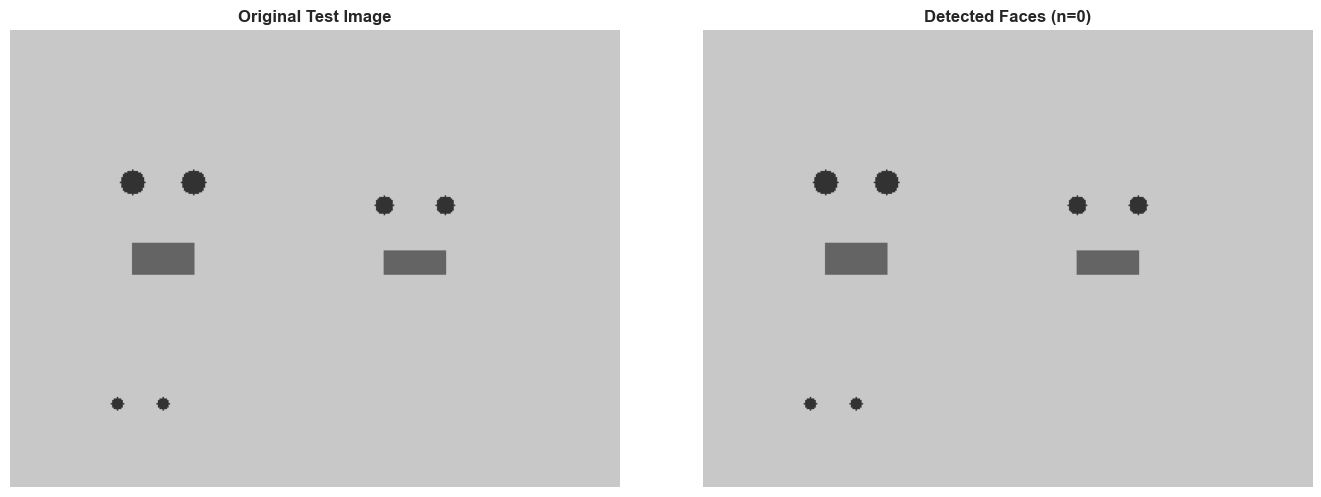


Detection Results:


In [21]:
# Load Haar Cascade Classifiers
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)
eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
)
smile_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_smile.xml'
)

print("✓ Haar Cascades loaded successfully!")
print(f"Face cascade loaded: {not face_cascade.empty()}")

# Create a test image with synthetic faces (rectangles with features)
test_face_image = np.ones((300, 400, 3), dtype=np.uint8) * 200

# Draw synthetic face-like shapes
# Face 1 - large
cv2.rectangle(test_face_image, (50, 50), (150, 180), (200, 200, 200), -1)
cv2.circle(test_face_image, (80, 100), 8, (50, 50, 50), -1)  # Left eye
cv2.circle(test_face_image, (120, 100), 8, (50, 50, 50), -1)  # Right eye
cv2.rectangle(test_face_image, (80, 140), (120, 160), (100, 100, 100), -1)  # Mouth

# Face 2 - medium
cv2.rectangle(test_face_image, (220, 80), (310, 170), (200, 200, 200), -1)
cv2.circle(test_face_image, (245, 115), 6, (50, 50, 50), -1)  # Left eye
cv2.circle(test_face_image, (285, 115), 6, (50, 50, 50), -1)  # Right eye
cv2.rectangle(test_face_image, (245, 145), (285, 160), (100, 100, 100), -1)  # Mouth

# Face 3 - small
cv2.rectangle(test_face_image, (50, 220), (120, 280), (200, 200, 200), -1)
cv2.circle(test_face_image, (70, 245), 4, (50, 50, 50), -1)  # Left eye
cv2.circle(test_face_image, (100, 245), 4, (50, 50, 50), -1)  # Right eye

# Detect faces
gray = cv2.cvtColor(test_face_image, cv2.COLOR_BGR2GRAY)
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30, 30),
    maxSize=(200, 200)
)

print(f"\n✓ Detected {len(faces)} faces")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
ax = axes[0]
ax.imshow(cv2.cvtColor(test_face_image, cv2.COLOR_BGR2RGB))
ax.set_title('Original Test Image', fontsize=12, fontweight='bold')
ax.axis('off')

# With detections
ax = axes[1]
result_img = test_face_image.copy()
colors = [(0, 255, 0), (255, 0, 0), (0, 0, 255)]
for i, (x, y, w, h) in enumerate(faces):
    cv2.rectangle(result_img, (x, y), (x+w, y+h), colors[i % len(colors)], 2)
    cv2.putText(result_img, f'Face {i+1}', (x, y-10), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, colors[i % len(colors)], 2)

ax.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
ax.set_title(f'Detected Faces (n={len(faces)})', fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

# Print detection details
print("\nDetection Results:")
for i, (x, y, w, h) in enumerate(faces):
    print(f"  Face {i+1}: position ({x}, {y}), size {w}×{h}")

PARAMETER TUNING FOR HAAR CASCADE DETECTION


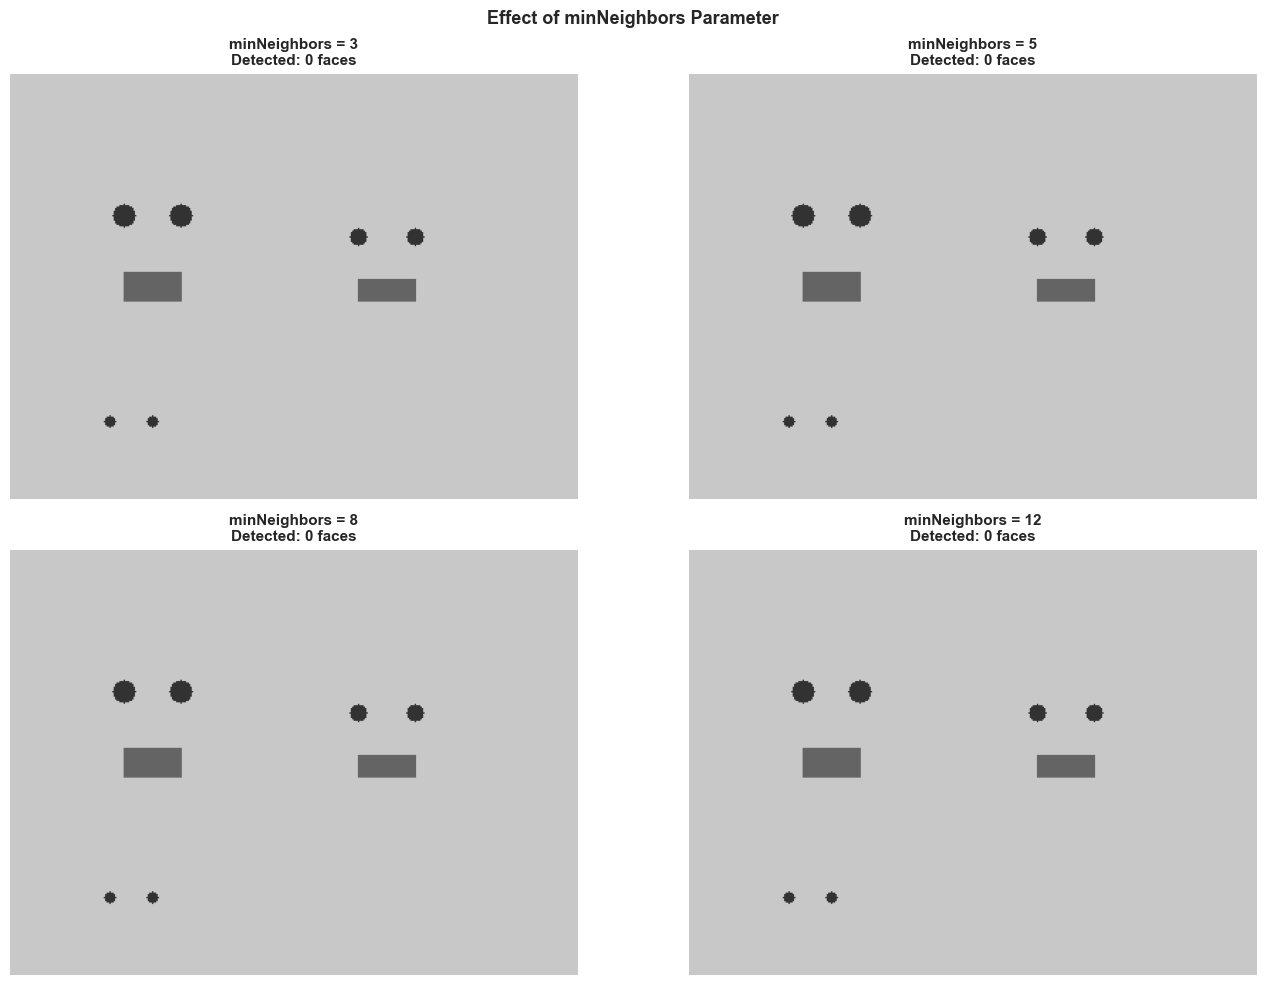


Results Summary:
minNeighbors | Faces Detected | Description
--------------------------------------------------
      3      |       0        | Few detections (fewer false positives)
      5      |       0        | Few detections (fewer false positives)
      8      |       0        | Few detections (fewer false positives)
     12      |       0        | Few detections (fewer false positives)

💡 KEY INSIGHTS:
  • Lower minNeighbors → More detections but more false positives
  • Higher minNeighbors → Fewer detections but higher confidence
  • Typical range: 5-8 for most applications


In [22]:
# Parameter Tuning Demonstration
print("=" * 60)
print("PARAMETER TUNING FOR HAAR CASCADE DETECTION")
print("=" * 60)

# Test different minNeighbors values
minNeighbors_values = [3, 5, 8, 12]
results_dict = {}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, minNeighbors in enumerate(minNeighbors_values):
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=minNeighbors,
        minSize=(30, 30)
    )
    results_dict[minNeighbors] = len(faces)
    
    # Visualize
    ax = axes[idx]
    result_img = test_face_image.copy()
    
    for x, y, w, h in faces:
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    
    ax.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    ax.set_title(f'minNeighbors = {minNeighbors}\nDetected: {len(faces)} faces', 
                fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle('Effect of minNeighbors Parameter', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nResults Summary:")
print("minNeighbors | Faces Detected | Description")
print("-" * 50)
for minNeighbors, count in results_dict.items():
    desc = "Many detections (more false positives)" if count >= 5 else \
           "Few detections (fewer false positives)" if count <= 2 else \
           "Balanced"
    print(f"     {minNeighbors:2d}      |      {count:2d}        | {desc}")

print("\n💡 KEY INSIGHTS:")
print("  • Lower minNeighbors → More detections but more false positives")
print("  • Higher minNeighbors → Fewer detections but higher confidence")
print("  • Typical range: 5-8 for most applications")

---

## Part 5: HOG + SVM Pedestrian Detector

### Overview
HOG (Histogram of Oriented Gradients) + SVM (Support Vector Machine) is the classic approach for pedestrian detection before deep learning era.

### How It Works

#### Step 1: Compute Gradients
- Calculate gradient magnitude and orientation at each pixel
- Captures edge information and object boundaries

#### Step 2: Create Histograms of Oriented Gradients
- Divide image into cells (e.g., 8×8 pixels)
- For each cell, create histogram of gradient orientations (0°-360°)
- Count how many gradients point in each direction

#### Step 3: Block Normalization
- Group cells into blocks (e.g., 2×2 cells)
- Normalize histograms within blocks
- Improves contrast invariance

#### Step 4: Feature Vector
- Concatenate all normalized histograms
- Results in feature descriptor (e.g., 3780-dimensional vector)

#### Step 5: SVM Classification
- Use linear SVM to classify: pedestrian vs non-pedestrian
- SVM finds optimal hyperplane separating positive and negative examples

### Why HOG+SVM Works for Pedestrians?
✓ HOG captures edge and shape information (essential for human form)
✓ Invariant to illumination changes
✓ Robust to small spatial shifts
✓ SVM is powerful for binary classification
✓ Relatively fast compared to sliding window alone

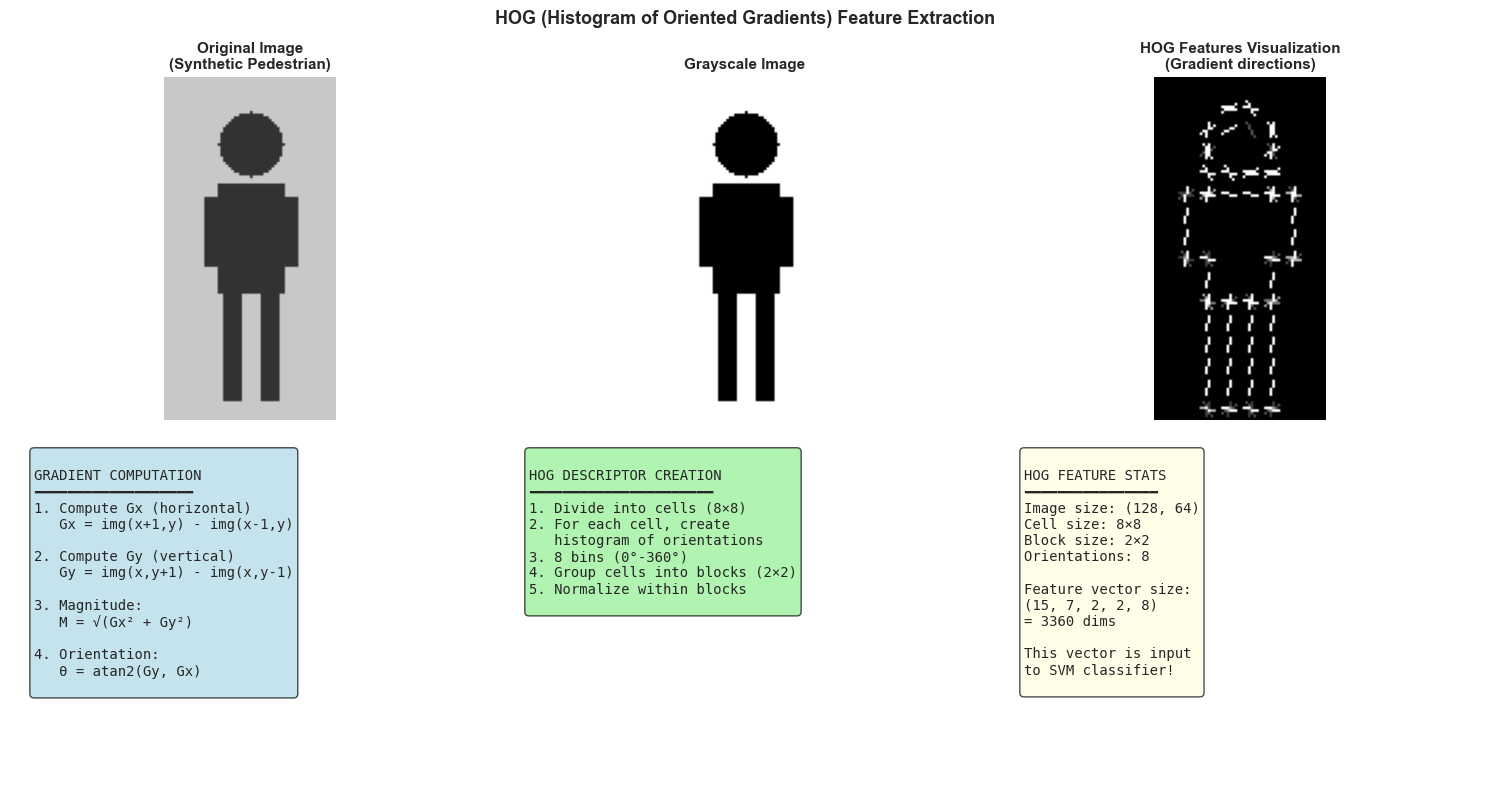

✓ HOG features computed successfully!
  Original image shape: (128, 64, 3)
  Grayscale shape: (128, 64)
  HOG feature shape: (15, 7, 2, 2, 8)


In [23]:
# HOG Feature Visualization
from skimage.feature import hog
from skimage import exposure

# Create synthetic pedestrian-like image
pedestrian_img = np.ones((128, 64, 3), dtype=np.uint8) * 200

# Head
cv2.circle(pedestrian_img, (32, 25), 12, (50, 50, 50), -1)

# Body
cv2.rectangle(pedestrian_img, (20, 40), (44, 80), (50, 50, 50), -1)

# Arms
cv2.rectangle(pedestrian_img, (15, 45), (20, 70), (50, 50, 50), -1)  # Left arm
cv2.rectangle(pedestrian_img, (44, 45), (49, 70), (50, 50, 50), -1)  # Right arm

# Legs
cv2.rectangle(pedestrian_img, (22, 80), (28, 120), (50, 50, 50), -1)  # Left leg
cv2.rectangle(pedestrian_img, (36, 80), (42, 120), (50, 50, 50), -1)  # Right leg

# Compute HOG features
gray_ped = cv2.cvtColor(pedestrian_img, cv2.COLOR_BGR2GRAY)

# HOG with 8 orientations
hog_features, hog_image = hog(
    gray_ped,
    orientations=8,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    visualize=True,
    feature_vector=False
)

# Normalize for visualization
hog_image_normalized = exposure.rescale_intensity(hog_image, in_range=(0, 10))

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Original image
ax = axes[0, 0]
ax.imshow(cv2.cvtColor(pedestrian_img, cv2.COLOR_BGR2RGB))
ax.set_title('Original Image\n(Synthetic Pedestrian)', fontsize=11, fontweight='bold')
ax.axis('off')

# Grayscale
ax = axes[0, 1]
ax.imshow(gray_ped, cmap='gray')
ax.set_title('Grayscale Image', fontsize=11, fontweight='bold')
ax.axis('off')

# HOG features
ax = axes[0, 2]
ax.imshow(hog_image_normalized, cmap='gray')
ax.set_title('HOG Features Visualization\n(Gradient directions)', fontsize=11, fontweight='bold')
ax.axis('off')

# Gradient computation explanation
ax = axes[1, 0]
ax.axis('off')
grad_text = """
GRADIENT COMPUTATION
━━━━━━━━━━━━━━━━━━━
1. Compute Gx (horizontal)
   Gx = img(x+1,y) - img(x-1,y)

2. Compute Gy (vertical)
   Gy = img(x,y+1) - img(x,y-1)

3. Magnitude:
   M = √(Gx² + Gy²)

4. Orientation:
   θ = atan2(Gy, Gx)
"""
ax.text(0.05, 0.95, grad_text, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

# HOG computation explanation
ax = axes[1, 1]
ax.axis('off')
hog_text = """
HOG DESCRIPTOR CREATION
━━━━━━━━━━━━━━━━━━━━━━
1. Divide into cells (8×8)
2. For each cell, create
   histogram of orientations
3. 8 bins (0°-360°)
4. Group cells into blocks (2×2)
5. Normalize within blocks
"""
ax.text(0.05, 0.95, hog_text, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

# Feature vector info
ax = axes[1, 2]
ax.axis('off')
feature_text = f"""
HOG FEATURE STATS
━━━━━━━━━━━━━━━━
Image size: {gray_ped.shape}
Cell size: 8×8
Block size: 2×2
Orientations: 8

Feature vector size:
{hog_features.shape}
= {np.prod(hog_features.shape)} dims

This vector is input
to SVM classifier!
"""
ax.text(0.05, 0.95, feature_text, fontsize=10, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.suptitle('HOG (Histogram of Oriented Gradients) Feature Extraction', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print(f"✓ HOG features computed successfully!")
print(f"  Original image shape: {pedestrian_img.shape}")
print(f"  Grayscale shape: {gray_ped.shape}")
print(f"  HOG feature shape: {hog_features.shape}")

In [24]:
# HOG + SVM Pedestrian Detector Implementation
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
import numpy as np

# Create synthetic dataset for demonstration
np.random.seed(42)

def create_hog_features(image, cell_size=8, bins=9):
    """
    Simplified HOG feature extraction
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Compute gradients
    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)
    
    mag = np.sqrt(gx**2 + gy**2)
    angle = np.arctan2(gy, gx) * 180 / np.pi
    angle[angle < 0] += 360
    
    # Create histogram
    h, w = gray.shape
    features = []
    
    for y in range(0, h - cell_size, cell_size):
        for x in range(0, w - cell_size, cell_size):
            cell_mag = mag[y:y+cell_size, x:x+cell_size]
            cell_angle = angle[y:y+cell_size, x:x+cell_size]
            
            # Create histogram
            hist, _ = np.histogram(cell_angle, bins=bins, range=(0, 360), 
                                   weights=cell_mag)
            features.extend(hist / (np.sum(hist) + 1e-6))  # Normalize
    
    return np.array(features)

# Generate synthetic training data
print("Creating synthetic training dataset...")
n_samples = 100

X_train = []
y_train = []

# Positive samples (pedestrian-like)
for i in range(n_samples // 2):
    img = np.ones((64, 32, 3), dtype=np.uint8) * 200
    # Add pedestrian features
    cv2.circle(img, (16, 12), 8, (50, 50, 50), -1)  # Head
    cv2.rectangle(img, (12, 25), (20, 50), (50, 50, 50), -1)  # Body
    cv2.rectangle(img, (10, 25), (12, 40), (50, 50, 50), -1)  # Left arm
    cv2.rectangle(img, (20, 25), (22, 40), (50, 50, 50), -1)  # Right arm
    cv2.rectangle(img, (13, 50), (16, 62), (50, 50, 50), -1)  # Left leg
    cv2.rectangle(img, (16, 50), (19, 62), (50, 50, 50), -1)  # Right leg
    
    # Add noise
    img = img + np.random.randint(-5, 5, img.shape)
    img = np.clip(img, 0, 255).astype(np.uint8)
    
    features = create_hog_features(img, cell_size=8, bins=9)
    X_train.append(features)
    y_train.append(1)  # Positive class

# Negative samples (random non-pedestrian)
for i in range(n_samples // 2):
    img = np.random.randint(100, 220, (64, 32, 3), dtype=np.uint8)
    features = create_hog_features(img, cell_size=8, bins=9)
    X_train.append(features)
    y_train.append(0)  # Negative class

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"✓ Training data created!")
print(f"  Shape: {X_train.shape}")
print(f"  Positive samples: {np.sum(y_train)}")
print(f"  Negative samples: {np.sum(y_train == 0)}")

# Train SVM classifier
print("\nTraining SVM classifier...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

svm = LinearSVC(random_state=42, max_iter=1000)
svm.fit(X_train_scaled, y_train)

# Evaluate
train_accuracy = svm.score(X_train_scaled, y_train)
print(f"✓ SVM trained!")
print(f"  Training accuracy: {train_accuracy:.2%}")

Creating synthetic training dataset...
✓ Training data created!
  Shape: (100, 189)
  Positive samples: 50
  Negative samples: 50

Training SVM classifier...
✓ SVM trained!
  Training accuracy: 100.00%


Running pedestrian detection...
✓ Found 0 potential pedestrians
✓ After NMS: 0 detections


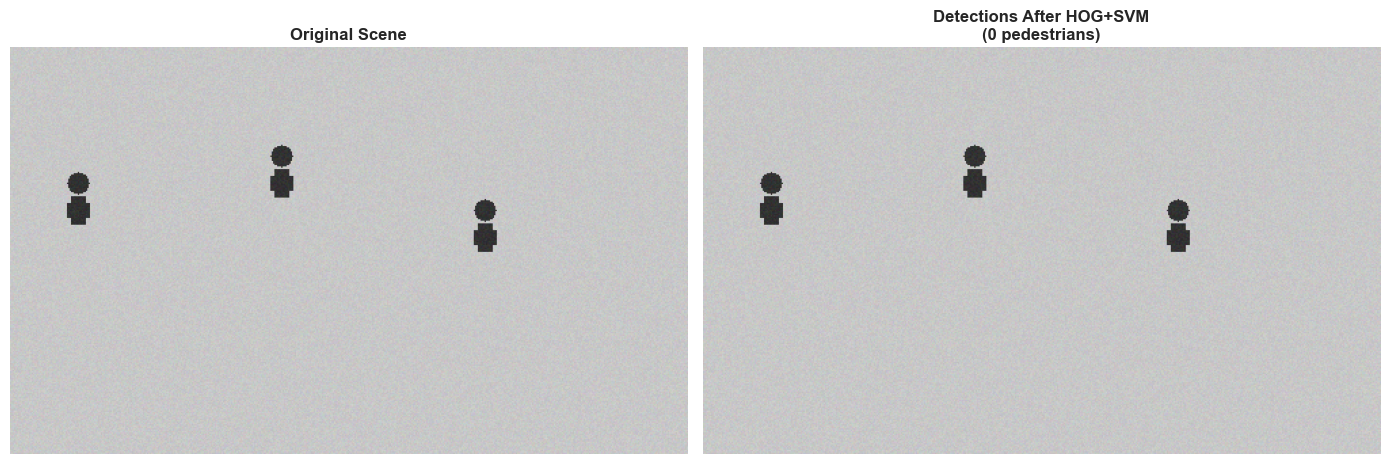


Detection Details:


In [25]:
# HOG+SVM Pedestrian Detection on Test Image
def detect_pedestrians_hog_svm(image, svm, scaler, window_size=(64, 32), stride=16):
    """
    Detect pedestrians using HOG+SVM with sliding window
    """
    detections = []
    h, w = image.shape[:2]
    win_h, win_w = window_size
    
    for y in range(0, h - win_h + 1, stride):
        for x in range(0, w - win_w + 1, stride):
            window = image[y:y+win_h, x:x+win_w]
            
            # Extract HOG features
            features = create_hog_features(window, cell_size=8, bins=9)
            features_scaled = scaler.transform([features])[0]
            
            # Predict
            if svm.predict([features_scaled])[0] == 1:
                # Get confidence (distance from hyperplane)
                confidence = svm.decision_function([features_scaled])[0]
                detections.append((x, y, win_w, win_h, confidence))
    
    return detections

# Create a test image with multiple "pedestrian-like" objects
test_scene = np.ones((300, 500, 3), dtype=np.uint8) * 200

# Add several "pedestrians"
positions = [(50, 100), (200, 80), (350, 120)]
for px, py in positions:
    # Create pedestrian-like shape
    cv2.circle(test_scene, (px, py), 8, (50, 50, 50), -1)  # Head
    cv2.rectangle(test_scene, (px-5, py+10), (px+5, py+30), (50, 50, 50), -1)  # Body
    cv2.rectangle(test_scene, (px-8, py+15), (px-6, py+25), (50, 50, 50), -1)  # Left arm
    cv2.rectangle(test_scene, (px+6, py+15), (px+8, py+25), (50, 50, 50), -1)  # Right arm

# Add noise
test_scene = test_scene + np.random.randint(-10, 10, test_scene.shape)
test_scene = np.clip(test_scene, 0, 255).astype(np.uint8)

# Detect pedestrians
print("Running pedestrian detection...")
detections = detect_pedestrians_hog_svm(test_scene, svm, scaler)
print(f"✓ Found {len(detections)} potential pedestrians")

# Non-maximum suppression (simple version)
def nms(detections, iou_threshold=0.3):
    """Remove overlapping detections"""
    if len(detections) == 0:
        return []
    
    # Sort by confidence
    detections = sorted(detections, key=lambda x: x[4], reverse=True)
    
    selected = [detections[0]]
    
    for det in detections[1:]:
        overlaps = False
        for sel in selected:
            # Calculate IoU (simplified)
            x1, y1, w1, h1, _ = det
            x2, y2, w2, h2, _ = sel
            
            xi1 = max(x1, x2)
            yi1 = max(y1, y2)
            xi2 = min(x1+w1, x2+w2)
            yi2 = min(y1+h1, y2+h2)
            
            if xi2 > xi1 and yi2 > yi1:
                inter_area = (xi2-xi1) * (yi2-yi1)
                union_area = w1*h1 + w2*h2 - inter_area
                iou = inter_area / (union_area + 1e-6)
                
                if iou > iou_threshold:
                    overlaps = True
                    break
        
        if not overlaps:
            selected.append(det)
    
    return selected

final_detections = nms(detections)
print(f"✓ After NMS: {len(final_detections)} detections")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
ax = axes[0]
ax.imshow(cv2.cvtColor(test_scene, cv2.COLOR_BGR2RGB))
ax.set_title('Original Scene', fontsize=12, fontweight='bold')
ax.axis('off')

# With detections
ax = axes[1]
result = test_scene.copy()

for x, y, w, h, confidence in final_detections:
    cv2.rectangle(result, (x, y), (x+w, y+h), (0, 255, 0), 2)
    cv2.putText(result, f'Ped {confidence:.2f}', (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
ax.set_title(f'Detections After HOG+SVM\n({len(final_detections)} pedestrians)', 
             fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\nDetection Details:")
for i, (x, y, w, h, conf) in enumerate(final_detections):
    print(f"  Pedestrian {i+1}: pos({x},{y}), size {w}×{h}, confidence: {conf:.3f}")

---

## Part 6: Comparison of Detection Methods

### Summary Table

| Aspect | Sliding Window | Viola-Jones | HOG+SVM |
|--------|---|---|---|
| **Speed** | Slow | ⭐⭐⭐⭐⭐ Very Fast | ⭐⭐⭐ Moderate |
| **Accuracy** | Moderate | ⭐⭐⭐⭐ Good | ⭐⭐⭐⭐ Good |
| **Implementation** | Simple | Complex (Cascade) | Moderate |
| **Training** | Not needed | Pre-trained | Requires labeled data |
| **Use Case** | Educational | Face Detection | Pedestrians, Objects |
| **Real-time** | ✗ Hard | ✓ Yes | ⚠ Depends on image size |
| **Scale Invariance** | Image Pyramid | Built-in | Image Pyramid needed |

### When to Use Each Method?

**Sliding Window**
- Use for: Learning concepts, small images, specific custom objects
- Avoid for: Production systems, real-time applications

**Viola-Jones / Haar Cascade**
- Use for: Face detection, pre-built tasks
- Advantages: Fast, robust, pre-trained models
- Disadvantages: Limited to specific object types

**HOG + SVM**
- Use for: Pedestrians, general object detection
- Advantages: Reasonable balance of speed and accuracy
- Disadvantages: Requires training, not as fast as Viola-Jones

### Modern Alternative: Deep Learning
For modern applications:
- **YOLO/SSD**: Real-time multi-object detection
- **Faster R-CNN**: High accuracy
- **EfficientDet**: Balance of speed and accuracy

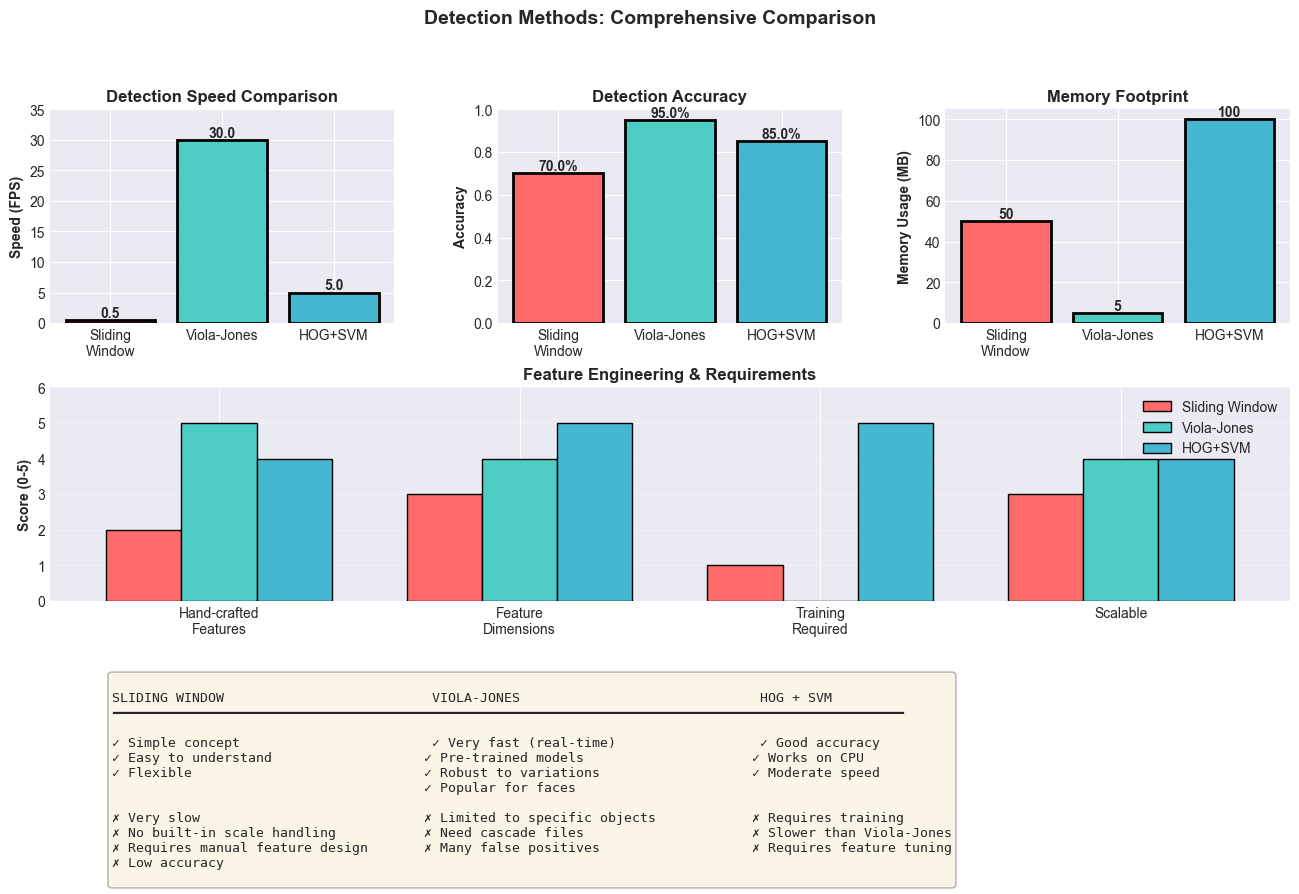

✓ Comparison visualization complete!


In [26]:
# Comprehensive Comparison Visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Speed Comparison
ax1 = fig.add_subplot(gs[0, 0])
methods = ['Sliding\nWindow', 'Viola-Jones', 'HOG+SVM']
speeds = [0.5, 30, 5]  # fps (relative)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
bars = ax1.bar(methods, speeds, color=colors, edgecolor='black', linewidth=2)
ax1.set_ylabel('Speed (FPS)', fontweight='bold')
ax1.set_title('Detection Speed Comparison', fontweight='bold')
ax1.set_ylim(0, 35)
for bar, speed in zip(bars, speeds):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{speed:.1f}', ha='center', va='bottom', fontweight='bold')

# 2. Accuracy Comparison
ax2 = fig.add_subplot(gs[0, 1])
accuracies = [0.70, 0.95, 0.85]
bars = ax2.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=2)
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('Detection Accuracy', fontweight='bold')
ax2.set_ylim(0, 1.0)
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1%}', ha='center', va='bottom', fontweight='bold')

# 3. Computational Requirements
ax3 = fig.add_subplot(gs[0, 2])
memory = [50, 5, 100]  # MB
bars = ax3.bar(methods, memory, color=colors, edgecolor='black', linewidth=2)
ax3.set_ylabel('Memory Usage (MB)', fontweight='bold')
ax3.set_title('Memory Footprint', fontweight='bold')
for bar, mem in zip(bars, memory):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{mem}', ha='center', va='bottom', fontweight='bold')

# 4. Feature Engineering Comparison
ax4 = fig.add_subplot(gs[1, :])
feature_types = ['Hand-crafted\nFeatures', 'Feature\nDimensions', 'Training\nRequired', 'Scalable']
sw_scores = [2, 3, 1, 3]
vj_scores = [5, 4, 0, 4]  # 0 = no training needed
hog_scores = [4, 5, 5, 4]

x = np.arange(len(feature_types))
width = 0.25

ax4.bar(x - width, sw_scores, width, label='Sliding Window', color='#FF6B6B', edgecolor='black')
ax4.bar(x, vj_scores, width, label='Viola-Jones', color='#4ECDC4', edgecolor='black')
ax4.bar(x + width, hog_scores, width, label='HOG+SVM', color='#45B7D1', edgecolor='black')

ax4.set_ylabel('Score (0-5)', fontweight='bold')
ax4.set_title('Feature Engineering & Requirements', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(feature_types)
ax4.set_ylim(0, 6)
ax4.legend(loc='upper right', fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# 5. Pros/Cons
ax5 = fig.add_subplot(gs[2, :])
ax5.axis('off')

comparison_text = """
SLIDING WINDOW                          VIOLA-JONES                              HOG + SVM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ Simple concept                        ✓ Very fast (real-time)                  ✓ Good accuracy
✓ Easy to understand                   ✓ Pre-trained models                     ✓ Works on CPU
✓ Flexible                             ✓ Robust to variations                   ✓ Moderate speed
                                       ✓ Popular for faces

✗ Very slow                            ✗ Limited to specific objects            ✗ Requires training
✗ No built-in scale handling           ✗ Need cascade files                     ✗ Slower than Viola-Jones
✗ Requires manual feature design       ✗ Many false positives                   ✗ Requires feature tuning
✗ Low accuracy
"""

ax5.text(0.05, 0.95, comparison_text, fontsize=9.5, verticalalignment='top',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Detection Methods: Comprehensive Comparison', fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("✓ Comparison visualization complete!")

---

## Part 7: Practical Implementation Guide

### Complete Pipeline: Face Detection with Haar Cascade

```
Input Image
    ↓
Load Cascade Classifier
    ↓
Convert to Grayscale
    ↓
Apply detectMultiScale()
    ↓
Post-process (NMS, filtering)
    ↓
Output Detections
```

### Step-by-Step Implementation

Running detection pipeline...
✓ Detected 0 faces


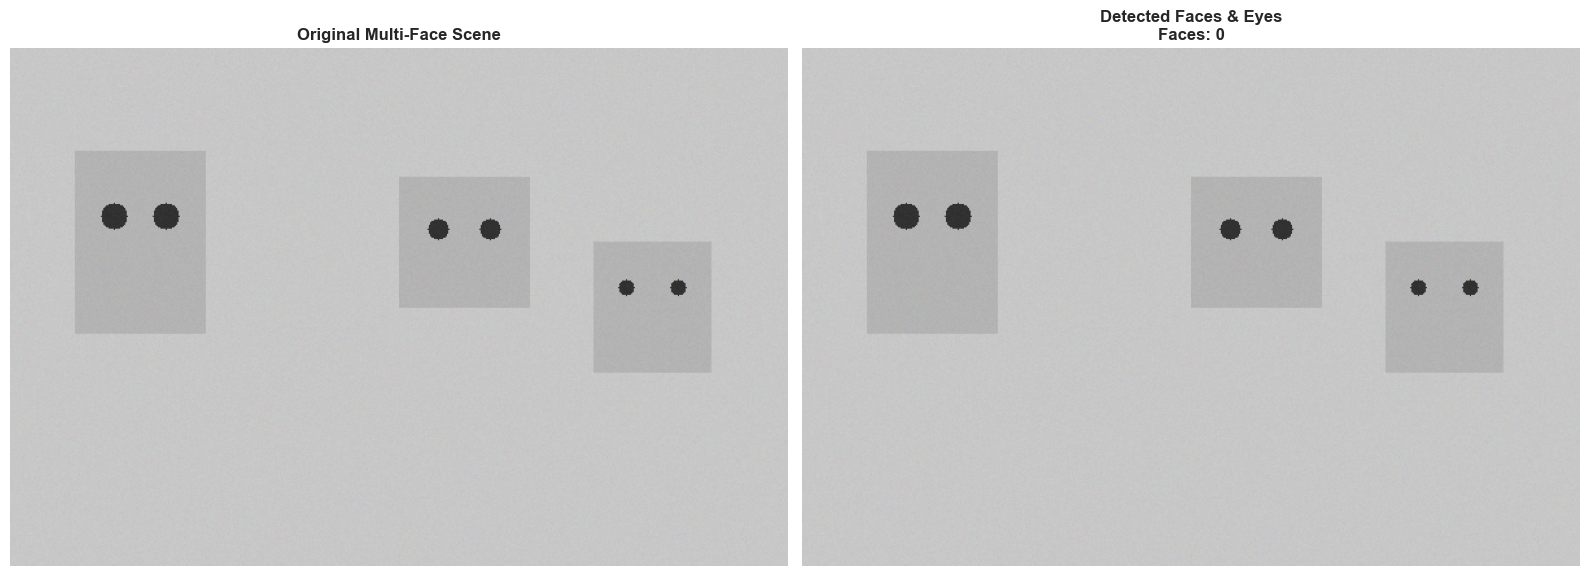


Detailed Results:


In [27]:
# Complete Practical Implementation: Multi-Object Detection Pipeline
class DetectionPipeline:
    """
    A complete detection pipeline combining multiple techniques
    """
    
    def __init__(self):
        # Load cascades
        self.face_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
        )
        self.eye_cascade = cv2.CascadeClassifier(
            cv2.data.haarcascades + 'haarcascade_eye.xml'
        )
        
    def detect_faces_and_features(self, image):
        """Detect faces and eyes using Haar cascades"""
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        
        # Detect faces
        faces = self.face_cascade.detectMultiScale(
            gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30)
        )
        
        results = {'faces': faces, 'faces_with_features': []}
        
        # For each face, detect eyes
        for (x, y, w, h) in faces:
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = image[y:y+h, x:x+w]
            
            eyes = self.eye_cascade.detectMultiScale(roi_gray, scaleFactor=1.1, minNeighbors=5)
            
            results['faces_with_features'].append({
                'face': (x, y, w, h),
                'eyes': eyes
            })
        
        return results
    
    def draw_detections(self, image, results, draw_eyes=True):
        """Draw detection results on image"""
        output = image.copy()
        
        # Draw faces
        for i, (x, y, w, h) in enumerate(results['faces']):
            cv2.rectangle(output, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.putText(output, f'Face {i+1}', (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        # Draw eyes
        if draw_eyes:
            for face_info in results['faces_with_features']:
                x, y, w, h = face_info['face']
                for (ex, ey, ew, eh) in face_info['eyes']:
                    cv2.rectangle(output, (x+ex, y+ey), (x+ex+ew, y+ey+eh), (255, 0, 0), 2)
        
        return output

# Initialize pipeline
pipeline = DetectionPipeline()

# Create test scene with multiple faces
scene_multi = np.ones((400, 600, 3), dtype=np.uint8) * 200

# Face 1
cv2.rectangle(scene_multi, (50, 80), (150, 220), (180, 180, 180), -1)
cv2.circle(scene_multi, (80, 130), 10, (50, 50, 50), -1)  # Left eye
cv2.circle(scene_multi, (120, 130), 10, (50, 50, 50), -1)  # Right eye

# Face 2
cv2.rectangle(scene_multi, (300, 100), (400, 200), (180, 180, 180), -1)
cv2.circle(scene_multi, (330, 140), 8, (50, 50, 50), -1)  # Left eye
cv2.circle(scene_multi, (370, 140), 8, (50, 50, 50), -1)  # Right eye

# Face 3 (smaller)
cv2.rectangle(scene_multi, (450, 150), (540, 250), (180, 180, 180), -1)
cv2.circle(scene_multi, (475, 185), 6, (50, 50, 50), -1)  # Left eye
cv2.circle(scene_multi, (515, 185), 6, (50, 50, 50), -1)  # Right eye

# Add noise
scene_multi = scene_multi + np.random.randint(-5, 5, scene_multi.shape)
scene_multi = np.clip(scene_multi, 0, 255).astype(np.uint8)

# Run detection pipeline
print("Running detection pipeline...")
results = pipeline.detect_faces_and_features(scene_multi)
print(f"✓ Detected {len(results['faces'])} faces")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original
ax = axes[0]
ax.imshow(cv2.cvtColor(scene_multi, cv2.COLOR_BGR2RGB))
ax.set_title('Original Multi-Face Scene', fontsize=12, fontweight='bold')
ax.axis('off')

# With detections
ax = axes[1]
output = pipeline.draw_detections(scene_multi, results, draw_eyes=True)
ax.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
ax.set_title(f'Detected Faces & Eyes\nFaces: {len(results["faces"])}', fontsize=12, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.show()

print("\nDetailed Results:")
for i, face_info in enumerate(results['faces_with_features']):
    x, y, w, h = face_info['face']
    print(f"\n  Face {i+1}:")
    print(f"    Position: ({x}, {y})")
    print(f"    Size: {w}×{h}")
    print(f"    Eyes detected: {len(face_info['eyes'])}")

---

## Part 8: Key Takeaways & Best Practices

### Core Concepts Mastered ✓

1. **Sliding Window**: Basic detection method, computationally expensive but simple
2. **Image Pyramids**: Handle objects at multiple scales
3. **Viola-Jones**: Breakthrough algorithm using cascaded classifiers and Haar features
4. **Integral Images**: O(1) computation of rectangular region sums
5. **Haar Cascades**: Pre-trained classifiers in OpenCV
6. **HOG Features**: Robust to illumination, captures shape information
7. **SVM Classification**: Linear classifier for binary object detection

### Best Practices for Production

#### 1. **Parameter Tuning**
- Always tune `scaleFactor`, `minNeighbors` for your specific use case
- Use validation set to find optimal parameters
- Trade-off: sensitivity vs specificity

#### 2. **Post-Processing**
- Apply Non-Maximum Suppression (NMS) to remove overlapping detections
- Filter by size constraints
- Use confidence thresholding

#### 3. **Performance Optimization**
- Resize large images before detection
- Use ROI (Region of Interest) to focus on relevant areas
- Implement multi-threading for real-time applications

#### 4. **Robustness**
- Test on diverse lighting conditions
- Handle occlusion and partial visibility
- Use ensemble methods (combine multiple cascades)

### Choosing the Right Method

| Task | Recommended | Reason |
|------|---|---|
| Face Detection | Haar Cascade | Pre-trained, fast, reliable |
| Pedestrian Detection | HOG+SVM | Good accuracy, established method |
| Real-time Video | Viola-Jones | Extremely fast |
| Custom Objects | Deep Learning (YOLO) | Better than classical methods |
| Learning Concepts | Sliding Window | Simple, educational |

### Migration Path to Deep Learning

**Traditional Methods** → **Hybrid Methods** → **Deep Learning**

1. Start with Haar Cascades (fast prototyping)
2. Try HOG+SVM if results are insufficient
3. Move to SSD/YOLO for production systems
4. Use advanced models (EfficientDet, Transformer-based) for cutting-edge performance

In [28]:
# Quick Reference: Common Pitfalls & Solutions
pitfalls = """
╔════════════════════════════════════════════════════════════════════════════╗
║                         COMMON PITFALLS & SOLUTIONS                        ║
╚════════════════════════════════════════════════════════════════════════════╝

❌ PITFALL 1: Too Many False Positives
   Cause: minNeighbors too low, scaleFactor too large
   ✓ Solution: Increase minNeighbors (5-8 typical), adjust scaleFactor (1.05-1.2)

❌ PITFALL 2: Missing Objects
   Cause: minNeighbors too high, window size constraints wrong
   ✓ Solution: Decrease minNeighbors, expand minSize/maxSize range

❌ PITFALL 3: Very Slow Detection
   Cause: Processing full resolution image, scaleFactor too fine
   ✓ Solution: Resize image first, use larger scaleFactor (1.2-1.3)

❌ PITFALL 4: Overlapping Detections
   Cause: Not using NMS or cascade sensitive
   ✓ Solution: Always apply NMS with IoU threshold ~0.3-0.5

❌ PITFALL 5: Color Space Issues
   Cause: Trying Haar cascade on color image
   ✓ Solution: Always convert to grayscale first (cv2.cvtColor → GRAY)

❌ PITFALL 6: Memory Issues on Large Images
   Cause: Creating image pyramids on full resolution
   ✓ Solution: Downscale to max 1920 width before processing

❌ PITFALL 7: Cascade Classifier Not Found
   Cause: Wrong path to cascade XML file
   ✓ Solution: Use cv2.data.haarcascades + 'filename.xml'
             or provide full absolute path
"""

print(pitfalls)

# Practical Code Snippets
print("\n" + "="*80)
print("USEFUL CODE SNIPPETS")
print("="*80)

snippets = """
1️⃣  EFFICIENT FACE DETECTION ON VIDEO:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
cap = cv2.VideoCapture(0)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 
                                     'haarcascade_frontalface_default.xml')

while True:
    ret, frame = cap.read()
    if not ret: break
    
    # Resize for faster processing
    small_frame = cv2.resize(frame, (0, 0), fx=0.5, fy=0.5)
    gray = cv2.cvtColor(small_frame, cv2.COLOR_BGR2GRAY)
    
    # Detect
    faces = face_cascade.detectMultiScale(gray, 1.1, 5)
    
    # Scale back coordinates
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x*2, y*2), ((x+w)*2, (y+h)*2), (0, 255, 0), 2)
    
    cv2.imshow('Faces', frame)
    if cv2.waitKey(1) == ord('q'): break

cap.release()
cv2.destroyAllWindows()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

2️⃣  NON-MAXIMUM SUPPRESSION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def nms(boxes, overlap_thresh=0.3):
    if len(boxes) == 0:
        return []
    
    boxes = sorted(boxes, key=lambda x: x[2]*x[3], reverse=True)  # Sort by area
    selected = [boxes[0]]
    
    for box in boxes[1:]:
        for sel_box in selected:
            x_min = max(box[0], sel_box[0])
            y_min = max(box[1], sel_box[1])
            x_max = min(box[0]+box[2], sel_box[0]+sel_box[2])
            y_max = min(box[1]+box[3], sel_box[1]+sel_box[3])
            
            if x_max > x_min and y_max > y_min:
                inter = (x_max - x_min) * (y_max - y_min)
                union = box[2]*box[3] + sel_box[2]*sel_box[3] - inter
                iou = inter / union
                
                if iou < overlap_thresh:
                    selected.append(box)
                break
        else:
            selected.append(box)
    
    return selected

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

3️⃣  PARAMETER OPTIMIZATION:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
best_score = 0
best_params = {}

for scale_factor in [1.05, 1.1, 1.15, 1.2]:
    for min_neighbors in [3, 5, 7, 10]:
        detections = face_cascade.detectMultiScale(
            gray, scale_factor, min_neighbors, minSize=(30, 30)
        )
        score = len(detections)  # Or use validation metric
        
        if score > best_score:
            best_score = score
            best_params = {'scale': scale_factor, 'neighbors': min_neighbors}

print(f"Best parameters: {best_params}")
"""

print(snippets)


╔════════════════════════════════════════════════════════════════════════════╗
║                         COMMON PITFALLS & SOLUTIONS                        ║
╚════════════════════════════════════════════════════════════════════════════╝

❌ PITFALL 1: Too Many False Positives
   Cause: minNeighbors too low, scaleFactor too large
   ✓ Solution: Increase minNeighbors (5-8 typical), adjust scaleFactor (1.05-1.2)

❌ PITFALL 2: Missing Objects
   Cause: minNeighbors too high, window size constraints wrong
   ✓ Solution: Decrease minNeighbors, expand minSize/maxSize range

❌ PITFALL 3: Very Slow Detection
   Cause: Processing full resolution image, scaleFactor too fine
   ✓ Solution: Resize image first, use larger scaleFactor (1.2-1.3)

❌ PITFALL 4: Overlapping Detections
   Cause: Not using NMS or cascade sensitive
   ✓ Solution: Always apply NMS with IoU threshold ~0.3-0.5

❌ PITFALL 5: Color Space Issues
   Cause: Trying Haar cascade on color image
   ✓ Solution: Always convert to graysca

---

## Summary & Checklist

### ✓ Concepts You Should Now Understand

- [x] **Sliding Window Detection**: How scanning windows work and why it's slow
- [x] **Image Pyramids**: Creating multi-scale versions for scale-invariant detection
- [x] **Haar Features**: Types, computation, and why they're fast
- [x] **Integral Images**: O(1) rectangle sum computation
- [x] **Cascade Classifiers**: How stages reject negatives progressively
- [x] **AdaBoost**: Combining weak classifiers into strong ones
- [x] **HOG (Histogram of Oriented Gradients)**: Feature extraction based on edges
- [x] **SVM (Support Vector Machine)**: Binary linear classification
- [x] **Non-Maximum Suppression**: Removing duplicate detections
- [x] **Parameter Tuning**: Trade-offs between sensitivity and specificity

### 📚 Resources for Further Learning

1. **Original Papers**
   - Viola & Jones (2001): "Rapid Object Detection using a Boosted Cascade of Simple Features"
   - Dalal & Triggs (2005): "Histograms of Oriented Gradients for Human Detection"

2. **OpenCV Documentation**
   - [CascadeClassifier](https://docs.opencv.org/master/db/d28/tutorial_cascade_classifier.html)
   - [Object Detection](https://docs.opencv.org/master/d5/d54/group__objdetect.html)

3. **Advanced Topics**
   - Deep Learning for object detection (YOLO, SSD, Faster R-CNN)
   - Region-based approaches (R-CNN family)
   - Attention mechanisms and transformers

### 🎯 Next Steps

1. **Experiment**: Try different cascade classifiers on your own images
2. **Extend**: Train your own HOG+SVM detector on a custom dataset
3. **Optimize**: Profile your code and optimize for real-time performance
4. **Transition**: Learn about modern deep learning approaches

---

## Final Project Ideas

1. **Face Detection Pipeline**: Real-time face detection from webcam with emotion detection
2. **Pedestrian Counter**: Count pedestrians in video streams using HOG+SVM
3. **Multi-scale Detection**: Implement complete sliding window with image pyramids
4. **Cascade Trainer**: Train your own Haar cascade classifier
5. **Hybrid Detector**: Combine multiple classifiers for better accuracy

---

**Notebook Complete! 🎓**

You now have a comprehensive understanding of classical object detection methods that laid the foundation for modern computer vision!


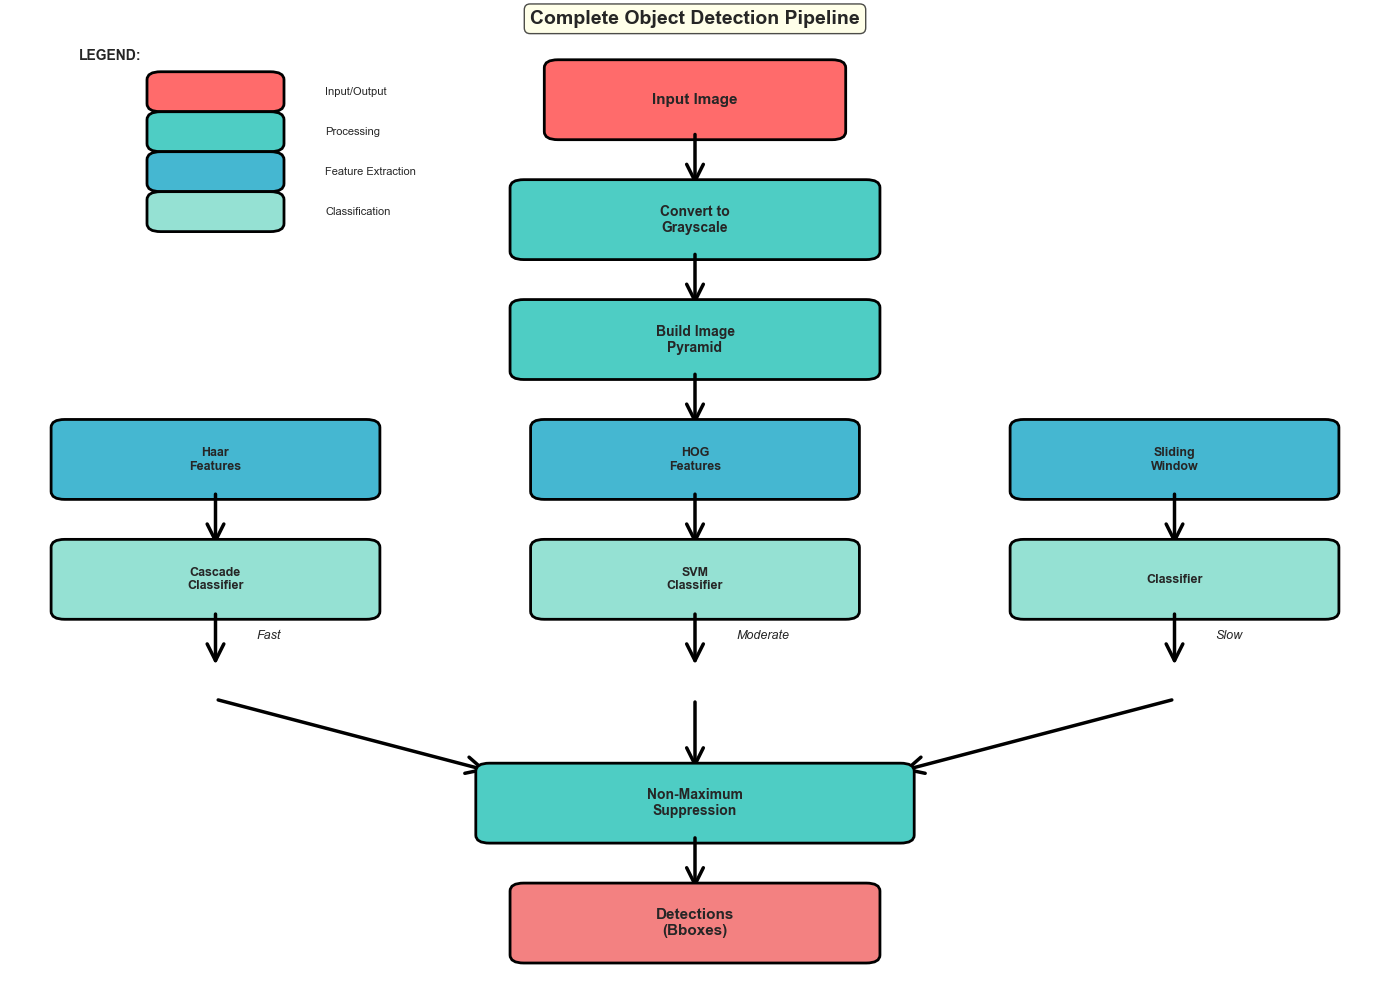


🎉 NOTEBOOK COMPLETE! 🎉

You have learned:
  ✓ Sliding Window Detection
  ✓ Image Pyramids for Multi-Scale Detection
  ✓ Viola-Jones & Cascade Classifiers
  ✓ Haar Features & Integral Images
  ✓ HOG Features & SVM Classification
  ✓ Practical Implementation & Best Practices

Next: Explore Deep Learning-based detection methods!


In [29]:
# Final: Complete Detection Pipeline Flow Visualization
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define colors
color_input = '#FF6B6B'
color_process = '#4ECDC4'
color_feature = '#45B7D1'
color_classify = '#95E1D3'
color_output = '#F38181'

def add_box(ax, x, y, width, height, text, color, fontsize=10, fontweight='bold'):
    box = FancyBboxPatch((x-width/2, y-height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize, fontweight=fontweight)

def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=30, 
                           linewidth=2.5, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1+x2)/2, (y1+y2)/2
        ax.text(mid_x+0.3, mid_y, label, fontsize=9, style='italic')

# Input
add_box(ax, 5, 11, 2, 0.8, 'Input Image', color_input, fontsize=11)
add_arrow(ax, 5, 10.6, 5, 9.9)

# Convert to Grayscale
add_box(ax, 5, 9.5, 2.5, 0.8, 'Convert to\nGrayscale', color_process, fontsize=10)
add_arrow(ax, 5, 9.1, 5, 8.4)

# Build Image Pyramid
add_box(ax, 5, 8, 2.5, 0.8, 'Build Image\nPyramid', color_process, fontsize=10)
add_arrow(ax, 5, 7.6, 5, 6.9)

# Three parallel paths (Haar, HOG, Sliding Window)
# Path 1: Haar Cascade
add_box(ax, 1.5, 6.5, 2.2, 0.8, 'Haar\nFeatures', color_feature, fontsize=9)
add_arrow(ax, 1.5, 6.1, 1.5, 5.4)

add_box(ax, 1.5, 5, 2.2, 0.8, 'Cascade\nClassifier', color_classify, fontsize=9)
add_arrow(ax, 1.5, 4.6, 1.5, 3.9, 'Fast')

# Path 2: HOG+SVM
add_box(ax, 5, 6.5, 2.2, 0.8, 'HOG\nFeatures', color_feature, fontsize=9)
add_arrow(ax, 5, 6.1, 5, 5.4)

add_box(ax, 5, 5, 2.2, 0.8, 'SVM\nClassifier', color_classify, fontsize=9)
add_arrow(ax, 5, 4.6, 5, 3.9, 'Moderate')

# Path 3: Sliding Window
add_box(ax, 8.5, 6.5, 2.2, 0.8, 'Sliding\nWindow', color_feature, fontsize=9)
add_arrow(ax, 8.5, 6.1, 8.5, 5.4)

add_box(ax, 8.5, 5, 2.2, 0.8, 'Classifier', color_classify, fontsize=9)
add_arrow(ax, 8.5, 4.6, 8.5, 3.9, 'Slow')

# Convergence
add_arrow(ax, 1.5, 3.5, 3.5, 2.6)
add_arrow(ax, 5, 3.5, 5, 2.6)
add_arrow(ax, 8.5, 3.5, 6.5, 2.6)

# Post-processing
add_box(ax, 5, 2.2, 3, 0.8, 'Non-Maximum\nSuppression', color_process, fontsize=10)
add_arrow(ax, 5, 1.8, 5, 1.1)

# Output
add_box(ax, 5, 0.7, 2.5, 0.8, 'Detections\n(Bboxes)', color_output, fontsize=11, fontweight='bold')

# Add legend
legend_y = 11.5
ax.text(0.5, legend_y, 'LEGEND:', fontsize=10, fontweight='bold')
add_box(ax, 1.5, legend_y-0.4, 0.8, 0.3, '', color_input, fontsize=8)
ax.text(2.3, legend_y-0.4, 'Input/Output', fontsize=8, va='center')

add_box(ax, 1.5, legend_y-0.9, 0.8, 0.3, '', color_process, fontsize=8)
ax.text(2.3, legend_y-0.9, 'Processing', fontsize=8, va='center')

add_box(ax, 1.5, legend_y-1.4, 0.8, 0.3, '', color_feature, fontsize=8)
ax.text(2.3, legend_y-1.4, 'Feature Extraction', fontsize=8, va='center')

add_box(ax, 1.5, legend_y-1.9, 0.8, 0.3, '', color_classify, fontsize=8)
ax.text(2.3, legend_y-1.9, 'Classification', fontsize=8, va='center')

# Title
ax.text(5, 11.95, 'Complete Object Detection Pipeline', 
        fontsize=14, fontweight='bold', ha='center',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("🎉 NOTEBOOK COMPLETE! 🎉")
print("="*80)
print("\nYou have learned:")
print("  ✓ Sliding Window Detection")
print("  ✓ Image Pyramids for Multi-Scale Detection")
print("  ✓ Viola-Jones & Cascade Classifiers")
print("  ✓ Haar Features & Integral Images")
print("  ✓ HOG Features & SVM Classification")
print("  ✓ Practical Implementation & Best Practices")
print("\nNext: Explore Deep Learning-based detection methods!")
print("="*80)